![alt text](<Pratech beyaz yazı logosu.png>)

In [ ]:
#Merhabalar Sayın Aday, Pratech stajyer alım sürecimizin teknik değerlendirme aşamasına hoş geldin.
# Senden isteğimiz aşağıdaki görevlerden birini seçmen ve bunu bizlere bu adresten teslim etmen:
# https://forms.gle/VbWCpUcmxakJmGLg7

#Sectigim Görev:
#Müşteri Kayıp Tahmini (Churn Prediction)

#Seçtiğiniz 1 görev üzerinde çalışarak,yapay zeka ve veri bilimi alanındaki yetkinliklerinizi göstermek için bu fırsatı
#en iyi şekilde değerlendirin.Her bir görevin amacı, gerçek dünya problemlerine yönelik çözümler üretme becerilerinizi ortaya koymaktır.
#Başarılar dileriz!


Merhabalar Sayın Aday, Pratech stajyer alım sürecimizin teknik değerlendirme aşamasına hoş geldin. Senden isteğimiz aşağıdaki görevlerden birini seçmen ve bunu bizlere bu adresten teslim etmen:   https://forms.gle/VbWCpUcmxakJmGLg7

Görev 7: Müşteri Kayıp Tahmini (Churn Prediction)
Senaryo: Yeni bir müşteri kazanmak, mevcut müşteriyi elde tutmaktan çok daha pahalıdır. Eğer bizi terk edecek (uygulamayı silecek veya bir daha alışveriş yapmayacak) müşterileri önceden tespit edebilirsek, onlara özel kampanyalarla geri kazanabiliriz.

Senden Ne İstiyoruz?
E-Ticaret sitesi müşterilerin demografik bilgilerini, kullanım alışkanlıklarını veya alışveriş geçmişini barındıran bir veri seti bul. Bu veriler üzerinden Random Forest, Logistic Regression veya LightGBM gibi bir Sınıflandırma (Classification) modeli kurarak "Hangi müşterilerin bizi terk etme ihtimali yüksek?" sorusuna yanıt bulmanı istiyoruz.

Nasıl Değerlendireceğiz? (Toplam 100 Puan)

Özellik Mühendisliği (Feature Engineering) (30 Puan): Sadece var olan veriyi kullanmak yerine, modelin işini kolaylaştıracak yeni anlamlı değişkenler (Örn: "Son 30 gündeki harcama değişimi") üretebilme becerin.

Model Eğitimi ve Denge (30 Puan): Kaybedilen müşteri sayısı genellikle azınlıktadır (Imbalanced Data). Bu dengesizliği (örneğin SMOTE kullanarak) nasıl yönettiğine ve modeli nasıl eğittiğine bakacağız.

Metrik Okuryazarlığı (20 Puan): Bu tarz problemlerde sadece doğruluğa (Accuracy) bakmak yanıltıcıdır. Precision, Recall, F1-Score ve Confusion Matrix gibi metrikleri kullanarak modelini nasıl yorumladığını görmek istiyoruz.

Aksiyon Önerisi (20 Puan): Notebook'un sonuna kısa bir yönetici notu düşmelisin: "Modelin riskli bulduğu %10'luk kesimi elde tutmak için şirket olarak şu adımları atmalıyız..."

In [ ]:
# Görev 7: Müşteri Kayıp Tahmini (Churn Prediction)


# Turkce biliyorum ama inglizcede daha net antabilirim diye inglizcede devam ettim.

# Churn Prediction

In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.preprocessing import LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV

from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.preprocessing import RobustScaler


from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import xgboost as xgb
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, matthews_corrcoef, roc_auc_score
)

## Data preprocessing

In [2]:
df = pd.read_csv("Churn_Modelling.csv")

In [3]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [5]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [6]:
# By checking this table, we can see our dataset does not have outlier.
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [7]:
print(df.shape)

(10000, 14)


In [8]:
print(f"Total Customers: {len(df)}")
print(f"Total features: {df.shape[1]}")
print(f"Total customers who left: {(df['Exited']==1).sum()} ({(df['Exited']==1).mean()*100:.1f})")
print(f"Total customes who stayed: {(df['Exited']==0).sum()} ({(df['Exited']==0).mean()*100:.1f})")
print(f"Imbalance Ratio (Stayed/Exited): {(df['Exited']==0).sum() / (df['Exited']== 1).sum():.2f}")

Total Customers: 10000
Total features: 14
Total customers who left: 2037 (20.4)
Total customes who stayed: 7963 (79.6)
Imbalance Ratio (Stayed/Exited): 3.91


In [9]:
# From our analyses we can see, there is class imbalance in our dataset.
# I will handle class imbalance by using SMOTE or we can train ensebmle models (Xgboost, Catboost etc)
# it can handle class imbalance by (class_weight = 'balanced')

In [10]:
total_bef = len(df)
duplicates = df.duplicated(subset='CustomerId', keep=False)
duplicates_count = duplicates.sum()
print(f"Total duplicate customers: {duplicates_count}")

if duplicates_count > 0:
    print(f"Duplicates: {df[duplicates][['CustomerId', 'Exited']].head()}")
    df = df.drop_duplicates(subset='CustomerId', keep='first')
    print(f"Total customers after removing duplicates: {len(df)}")
else:
  print("No duplicated found.")

Total duplicate customers: 0
No duplicated found.


In [11]:
# We can see our datset do not have any duplicates.

In [12]:
missing_values = df.isnull().sum()
missing_percentage = (missing_values.sum() / len(df) *100).round(2)
missing_report = pd.DataFrame({'Missing_Values': missing_values,
                               'Percentage': missing_percentage}).sort_values(by='Percentage', ascending=False)
missing_report = missing_report[missing_report['Missing_Values']>0]
print(missing_report)

Empty DataFrame
Columns: [Missing_Values, Percentage]
Index: []


In [13]:
# As we can see there are no any missing values in dataset.
# Otherwise i would handle dataset with different ways. The important thing when working with
# missing values. We need to understand concept of dataset then type of missing value.
# for numerical missing values we can use mean, median and 0. for categorical values we can use mode.
# using 0 everytime is not good option, thats why we need to understand dataset itself first.

## Data Visualization

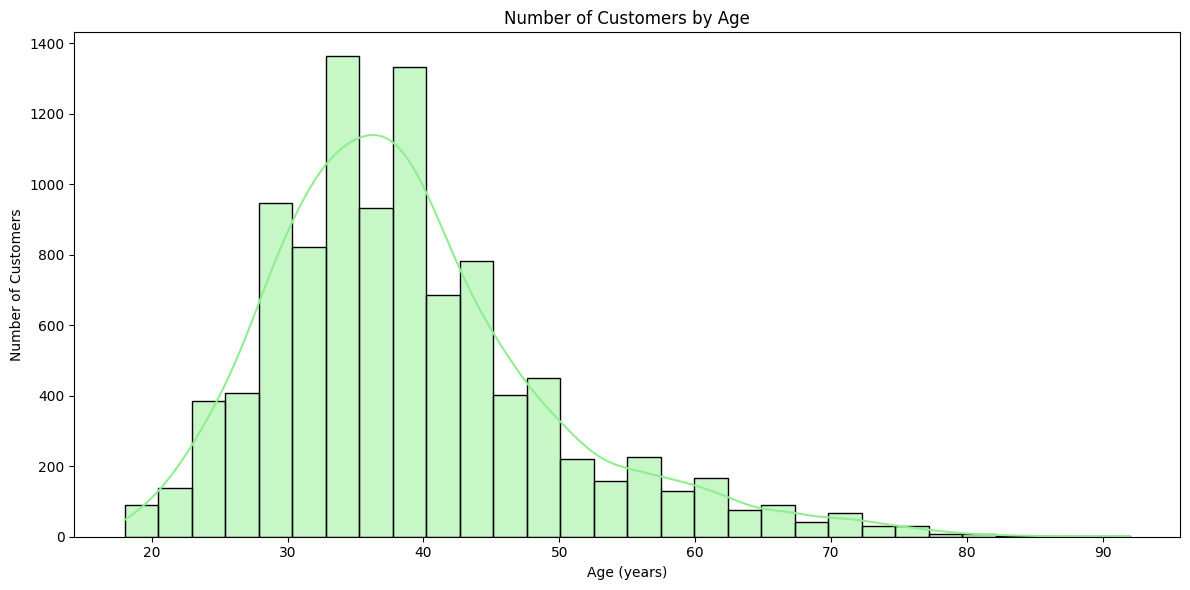

In [14]:
plt.figure(figsize=(12, 6))


sns.histplot(
    x=df["Age"],
    bins=30,
    kde=True,
    color="lightgreen",
    edgecolor="black"
)

plt.title("Number of Customers by Age")
plt.xlabel("Age (years)")
plt.ylabel("Number of Customers")

# Show every age tick on x-axis
# plt.xticks(dataset["Age"].values)

plt.tight_layout()
plt.show()

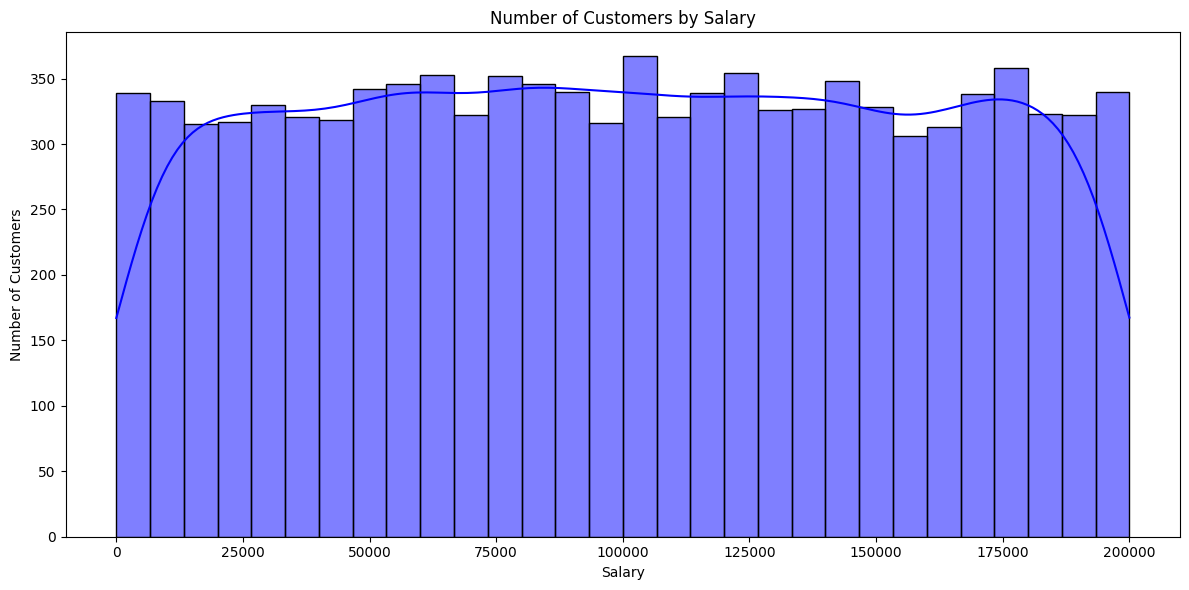

In [15]:
plt.figure(figsize=(12, 6))


sns.histplot(
    x=df["EstimatedSalary"],
    bins=30,
    kde=True,
    color="blue",
    edgecolor="black"
)

plt.title("Number of Customers by Salary")
plt.xlabel("Salary")
plt.ylabel("Number of Customers")

# Show every age tick on x-axis
# plt.xticks(dataset["Age"].values)

plt.tight_layout()
plt.show()

In [16]:
churn_counts = df['Exited'].value_counts().reset_index()
churn_counts.columns = ['Exited', 'Count']

fig = px.pie(churn_counts, values='Count', names='Exited',
             title='Churn Distribution (0: Stayed, 1: Exited)',
             labels={'0': 'Stayed', '1': 'Exited'})

fig.update_traces(textposition='inside', textinfo='percent+label')
fig.show()

In [17]:
churn_by_geography = df.groupby('Geography')['Exited'].mean().reset_index()
churn_by_geography['Exited'] = churn_by_geography['Exited'] * 100

fig = px.bar(churn_by_geography, x='Geography', y='Exited',
             title='Churn Rate by Geography',
             labels={'Exited': 'Churn Rate (%)'}, color='Geography')
fig.update_layout(yaxis_range=[0, 100])
fig.show()

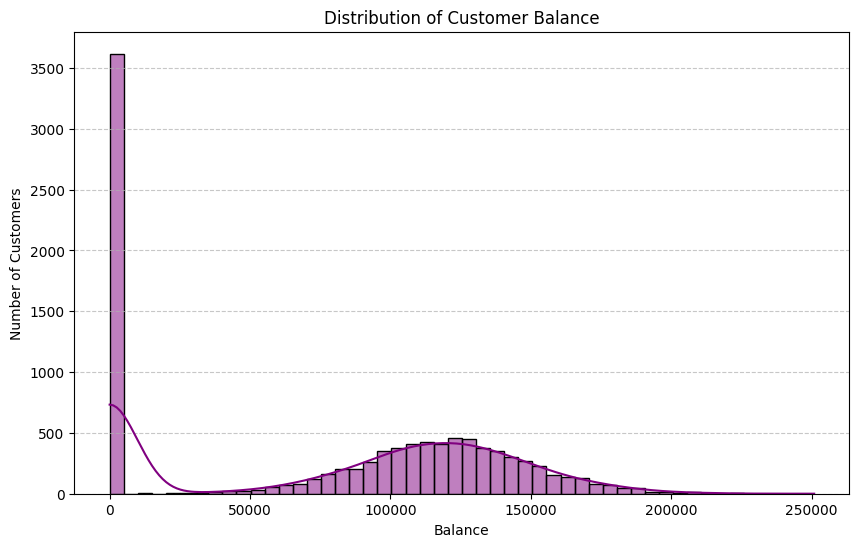

In [18]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Balance'], kde=True, bins=50, color='purple')
plt.title('Distribution of Customer Balance')
plt.xlabel('Balance')
plt.ylabel('Number of Customers')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [19]:
print(df['Balance'].mean())

76485.889288


## Feature Engineering

In [20]:
df['BankSalaryRatio'] = df['Balance'] / (df['EstimatedSalary'] + 1e-9) # avoid dividing zero

# if person has low ratio it means person earning money but he is not keep it in bank.
# that means this person might invest new things and might working with another bank
# which high chance to leave

# if it is high ratio, this means less likely to leave

In [21]:
df['LifeStage'] = ['young' if age < 35 else 'middle-age' if 35 <= age < 60 else 'senior' for age in df['Age']]

# we should analyse churn percentage by age.
# most likely senior people hard to leave than young people

In [22]:
# interaction_list = []

# for i in range(len(df)):
#   if df['IsActiveMember'][i] == 1 and df['Balance'][i] > df['Balance'].mean():
#     interaction_list.append('engaged')
#   elif df['IsActiveMember'][i] == 0 and df['Balance'][i] > df['Balance'].mean():
#     interaction_list.append('danger_zone')
#   else:
#     interaction_list.append('not_engaged')

# df['Interaction'] = interaction_list

condition = [
    (df['IsActiveMember'] == 1) & (df['Balance'] > df['Balance'].mean()),
    (df['IsActiveMember'] == 0) & (df['Balance'] > df['Balance'].mean())
]

choices = ['engaged', 'danger_zone']

df['Interaction'] = np.select(condition, choices, default='not_engaged')



# well in here. i think active member and high balance in account is like more hard to leave
# inactive and high balance is like danger zone, likely to leave
# inactive and 0 or less than average is already gone.

In [23]:
# tenure_product = []

# for i in range(len(df)):
#   if df['Tenure'][i] > 5 and df['NumOfProducts'][i] > 1:
#     tenure_product.append('engaged')
#   elif df['Tenure'][i] < 5 and df['NumOfProducts'][i] > 1:
#     tenure_product.append('more_engaged')
#   elif df['Tenure'][i] > 5 and df['NumOfProducts'][i] == 1:
#     tenure_product.append('less_engaged')
#   else:
#     tenure_product.append('not_engaged')

# df['Tenure_Product'] = tenure_product


conditions = [
    (df['Tenure'] > 5) & (df['NumOfProducts'] > 1),
    (df['Tenure'] < 5) & (df['NumOfProducts'] > 1),
    (df['Tenure'] > 5) & (df['NumOfProducts'] == 1),
]

choices = ['engaged', 'more_engaged', 'less_engaged']

df['Tenure_Product'] = np.select(conditions, choices, default='not_engaged')

# well in here. I think person who has more product in company and tenure (year he has been) is high
# this person hard to leave, deeply embedded

# but other are not deeply engaged.

In [24]:
df['CreditScore_Category'] = ['poor' if score <= 300
                              else 'fair' if score <= 500
                              else 'good' if score <= 600
                              else 'very_good' if score <= 700
                              else 'excellent' for score in df['CreditScore']]

# we should analyse churn percentage.
# in here based on credit score real companies and banks categorize them.

In [25]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,BankSalaryRatio,LifeStage,Interaction,Tenure_Product,CreditScore_Category
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,0.000000,middle-age,not_engaged,not_engaged,very_good
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,0.744677,middle-age,engaged,not_engaged,very_good
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1.401375,middle-age,danger_zone,engaged,good
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0.000000,middle-age,not_engaged,more_engaged,very_good
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,1.587055,middle-age,engaged,not_engaged,excellent


In [26]:
churn_by_lifestage = df.groupby('LifeStage')['Exited'].mean().reset_index()
churn_by_lifestage['Exited'] = churn_by_lifestage['Exited'] * 100

fig = px.pie(churn_by_lifestage, values='Exited', names='LifeStage',
             title='Churn Rate by LifeStage',
             labels={'Exited': 'Churn Rate (%)'})
fig.update_traces(textposition='inside', textinfo='percent+label')
fig.show()

In [27]:
churn_by_interaction = df.groupby('Interaction')['Exited'].mean().reset_index()
churn_by_interaction['Exited'] = churn_by_interaction['Exited'] * 100

fig = px.pie(churn_by_interaction, values='Exited', names='Interaction',
             title='Churn Rate by Interaction',
             labels={'Exited': 'Churn Rate (%)'})
fig.update_traces(textposition='inside', textinfo='percent+label')
fig.show()

In [28]:
# in the above, pie chart shows that. engaged people are leaving more than not_engaged, intersting!
# I think, i miss something or didnt understand realtionships between balance and active status
# but as we said, danger zone is more important. so we can keep as it is.

In [29]:
churn_by_score = df.groupby('CreditScore_Category')['Exited'].mean().reset_index()
churn_by_score['Exited'] = churn_by_score['Exited'] * 100

fig = px.pie(churn_by_score, values='Exited', names='CreditScore_Category',
             title='Churn Rate by CreditScore_Category',
             labels={'Exited': 'Churn Rate (%)'})
fig.update_traces(textposition='inside', textinfo='percent+label')
fig.show()

In [ ]:
df.to_csv("Churn_dataset.csv", index=False)

## Encoding Categorical Variables

In [30]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns found: {cat_cols}")

Categorical columns found: ['Surname', 'Geography', 'Gender', 'LifeStage', 'Interaction', 'Tenure_Product', 'CreditScore_Category']


In [31]:
le = LabelEncoder()

df['Gender'] = le.fit_transform(df['Gender'])

# gender is binary, thats why i used label encoder for it

In [32]:
df = pd.get_dummies(df, columns=['Geography', 'LifeStage', 'Interaction', 'Tenure_Product', 'CreditScore_Category'])

# i am using get dummies function coz these features are not binary

In [33]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,...,Interaction_engaged,Interaction_not_engaged,Tenure_Product_engaged,Tenure_Product_less_engaged,Tenure_Product_more_engaged,Tenure_Product_not_engaged,CreditScore_Category_excellent,CreditScore_Category_fair,CreditScore_Category_good,CreditScore_Category_very_good
0,1,15634602,Hargrave,619,0,42,2,0.00,1,1,...,False,True,False,False,False,True,False,False,False,True
1,2,15647311,Hill,608,0,41,1,83807.86,1,0,...,True,False,False,False,False,True,False,False,False,True
2,3,15619304,Onio,502,0,42,8,159660.80,3,1,...,False,False,True,False,False,False,False,False,True,False
3,4,15701354,Boni,699,0,39,1,0.00,2,0,...,False,True,False,False,True,False,False,False,False,True
4,5,15737888,Mitchell,850,0,43,2,125510.82,1,1,...,True,False,False,False,False,True,True,False,False,False


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 31 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   RowNumber                       10000 non-null  int64  
 1   CustomerId                      10000 non-null  int64  
 2   Surname                         10000 non-null  object 
 3   CreditScore                     10000 non-null  int64  
 4   Gender                          10000 non-null  int64  
 5   Age                             10000 non-null  int64  
 6   Tenure                          10000 non-null  int64  
 7   Balance                         10000 non-null  float64
 8   NumOfProducts                   10000 non-null  int64  
 9   HasCrCard                       10000 non-null  int64  
 10  IsActiveMember                  10000 non-null  int64  
 11  EstimatedSalary                 10000 non-null  float64
 12  Exited                          1

## Feature Selection

In [35]:
df.shape

(10000, 31)

In [36]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Gender', 'Age',
       'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
       'EstimatedSalary', 'Exited', 'BankSalaryRatio', 'Geography_France',
       'Geography_Germany', 'Geography_Spain', 'LifeStage_middle-age',
       'LifeStage_senior', 'LifeStage_young', 'Interaction_danger_zone',
       'Interaction_engaged', 'Interaction_not_engaged',
       'Tenure_Product_engaged', 'Tenure_Product_less_engaged',
       'Tenure_Product_more_engaged', 'Tenure_Product_not_engaged',
       'CreditScore_Category_excellent', 'CreditScore_Category_fair',
       'CreditScore_Category_good', 'CreditScore_Category_very_good'],
      dtype='object')

In [37]:
df = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'], axis=1)

# i dropped these columns, because they do not effect anything for model to learn

In [38]:
df_corr = df.corr().abs()

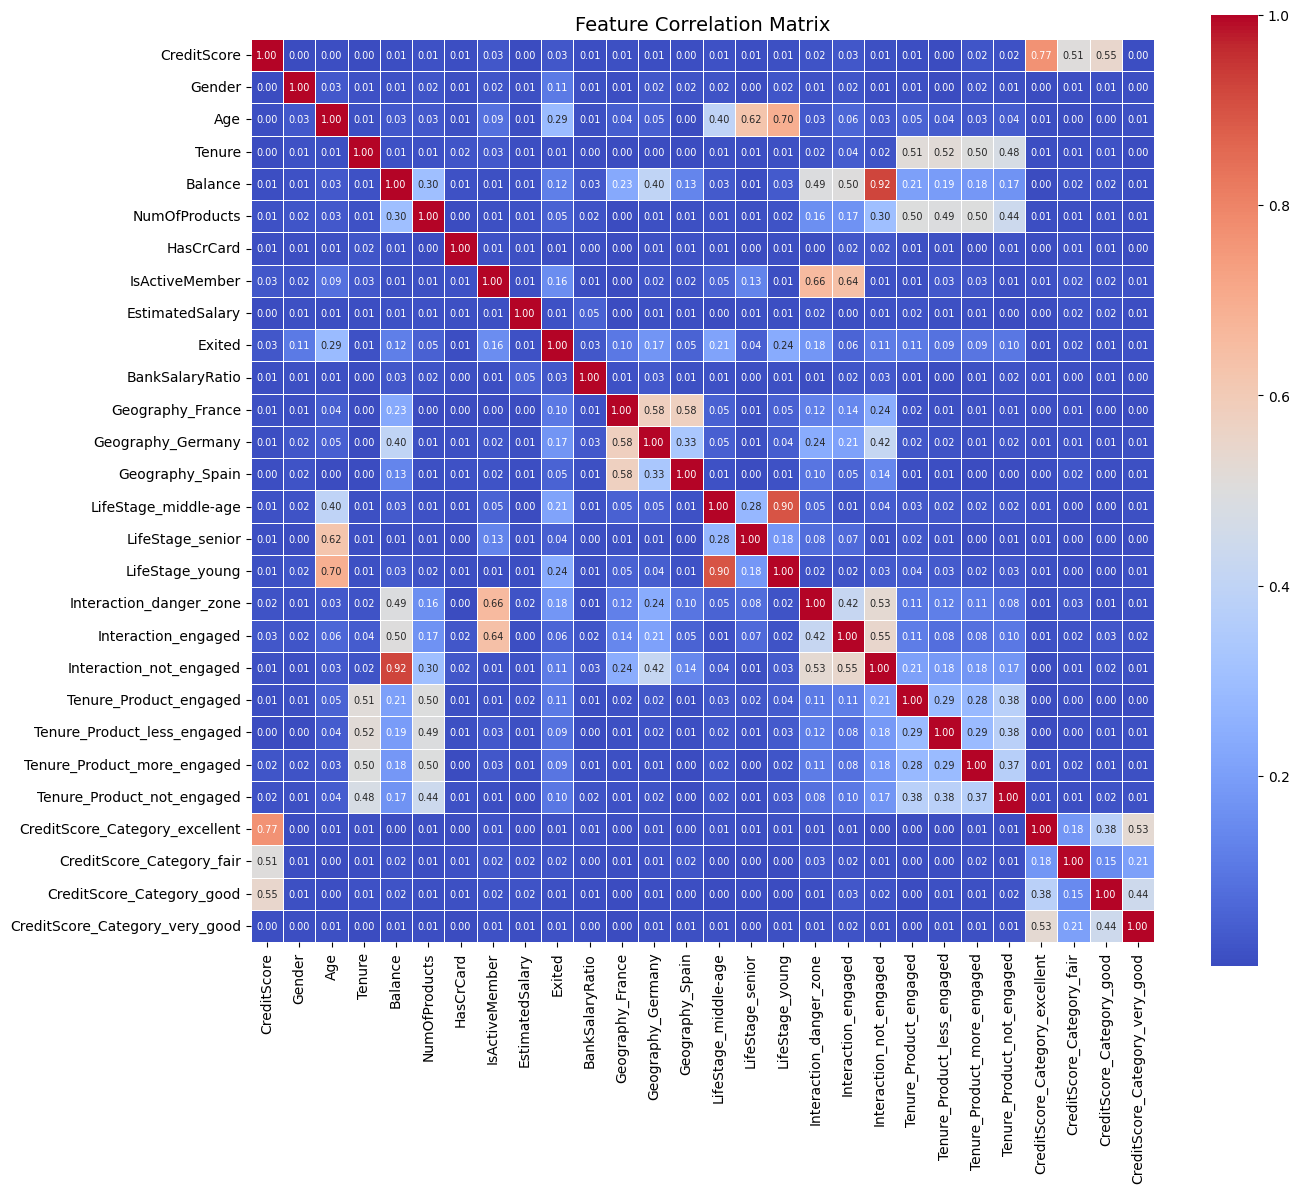

In [39]:
plt.figure(figsize=(14, 12))
sns.heatmap(
    df_corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    square=True,
    linewidths=0.5,
    annot_kws={'size': 7}
)
plt.title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

In [40]:
# well as you can see there is no any features which correlated very high. so we do not need to
# drop any feature in case of data leakage

In [41]:
high_corr_pairs = []
cols = df_corr.columns

for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        if df_corr.iloc[i, j] > 0.95:
            high_corr_pairs.append({
                'feature_1': cols[i],
                'feature_2': cols[j],
                'correlation': round(df_corr.iloc[i, j], 4)
            })

if high_corr_pairs:
    print(f"High correlation pairs (>0.95):")
    for pair in high_corr_pairs:
        print(f"  {pair['feature_1']} vs {pair['feature_2']}: {pair['correlation']}")
else:
    print("No feature pairs with correlation > 0.95 found!")

No feature pairs with correlation > 0.95 found!


In [42]:
df.columns

Index(['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
       'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited',
       'BankSalaryRatio', 'Geography_France', 'Geography_Germany',
       'Geography_Spain', 'LifeStage_middle-age', 'LifeStage_senior',
       'LifeStage_young', 'Interaction_danger_zone', 'Interaction_engaged',
       'Interaction_not_engaged', 'Tenure_Product_engaged',
       'Tenure_Product_less_engaged', 'Tenure_Product_more_engaged',
       'Tenure_Product_not_engaged', 'CreditScore_Category_excellent',
       'CreditScore_Category_fair', 'CreditScore_Category_good',
       'CreditScore_Category_very_good'],
      dtype='object')

## Train Test split

In [43]:
X = df.drop('Exited', axis=1)
y = df['Exited']

In [44]:
X.columns

Index(['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
       'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'BankSalaryRatio',
       'Geography_France', 'Geography_Germany', 'Geography_Spain',
       'LifeStage_middle-age', 'LifeStage_senior', 'LifeStage_young',
       'Interaction_danger_zone', 'Interaction_engaged',
       'Interaction_not_engaged', 'Tenure_Product_engaged',
       'Tenure_Product_less_engaged', 'Tenure_Product_more_engaged',
       'Tenure_Product_not_engaged', 'CreditScore_Category_excellent',
       'CreditScore_Category_fair', 'CreditScore_Category_good',
       'CreditScore_Category_very_good'],
      dtype='object')

There are couple problems that i am facing now.

**First problem**:
Once we created new features, we should remove raw features. such as, we create 'LifeStage' from raw 'Age' feature. in this case, i should drop 'Age' feature, but in the requirements of this project, it didnt mention that can i remove it or not.

Well, it is fine if i keep it both raw and created features but i need to take risk of multicollinearity.

My model might split importance scores between correlated features making both look weak when actually together they are strong. So we will find out when we see the feature importance after training model


**Second problem:**
I think 'HasCrCard' is dead weight. because, does having a credit card actually predict churn meaningfully?. No it doesnt. basically we do not need it. imaportance of feature most probably zero for this feature.

Still i will keep it


In [45]:
y.value_counts()

,count
Exited,
0,7963
1,2037


In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# as long as we are not using deep learning algorithms, and this problem is classic ML problem
# train and test sets are enough. no need for validation set

In [47]:
counter = Counter(y_train)
print('Before', counter)

smt = SMOTE(random_state=42)
X_train_sm, y_train_sm = smt.fit_resample(X_train, y_train)

counter = Counter(y_train_sm)
print('After', counter)

# we should only apply training set for SMOTE, otherwise it would be data leakage

Before Counter({0: 5574, 1: 1426})
After Counter({0: 5574, 1: 5574})


## Scaling or normalization

In [48]:
X_train_sm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11148 entries, 0 to 11147
Data columns (total 27 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   CreditScore                     11148 non-null  int64  
 1   Gender                          11148 non-null  int64  
 2   Age                             11148 non-null  int64  
 3   Tenure                          11148 non-null  int64  
 4   Balance                         11148 non-null  float64
 5   NumOfProducts                   11148 non-null  int64  
 6   HasCrCard                       11148 non-null  int64  
 7   IsActiveMember                  11148 non-null  int64  
 8   EstimatedSalary                 11148 non-null  float64
 9   BankSalaryRatio                 11148 non-null  float64
 10  Geography_France                11148 non-null  bool   
 11  Geography_Germany               11148 non-null  bool   
 12  Geography_Spain                 

In [49]:
num_cols = X_train_sm.select_dtypes(include=['float64', 'int64']).columns.tolist()
print(num_cols)

['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'BankSalaryRatio']


In [50]:
numerical_list = ['CreditScore', 'Age', 'Balance', 'EstimatedSalary', 'BankSalaryRatio']

In [51]:
robust_scaler = RobustScaler()

X_train_sm[numerical_list] = robust_scaler.fit_transform(X_train_sm[numerical_list])
X_test[numerical_list] = robust_scaler.transform(X_test[numerical_list])

In [52]:
X_train_sm.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,BankSalaryRatio,...,Interaction_engaged,Interaction_not_engaged,Tenure_Product_engaged,Tenure_Product_less_engaged,Tenure_Product_more_engaged,Tenure_Product_not_engaged,CreditScore_Category_excellent,CreditScore_Category_fair,CreditScore_Category_good,CreditScore_Category_very_good
0,-0.435484,1,-1.538462,4,-0.056540,1,1,0,0.787166,-0.167851,...,False,False,False,False,False,True,False,False,True,False
1,0.322581,0,1.769231,1,-0.800368,2,1,1,0.876110,-0.502128,...,False,True,False,False,True,False,False,False,False,True
2,1.330645,1,-0.692308,1,0.122298,1,1,0,0.017536,0.222512,...,False,False,False,False,False,True,True,False,False,False
3,0.588710,1,-1.538462,6,-0.800368,2,1,0,0.966806,-0.502128,...,False,True,True,False,False,False,True,False,False,False
4,0.717742,1,-1.692308,4,-0.800368,2,1,1,-0.528095,-0.502128,...,False,True,False,False,True,False,True,False,False,False


In [53]:
X_test.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,BankSalaryRatio,...,Interaction_engaged,Interaction_not_engaged,Tenure_Product_engaged,Tenure_Product_less_engaged,Tenure_Product_more_engaged,Tenure_Product_not_engaged,CreditScore_Category_excellent,CreditScore_Category_fair,CreditScore_Category_good,CreditScore_Category_very_good
6417,1.137097,1,-0.230769,6,-0.800368,2,1,1,0.197505,-0.502128,...,False,True,True,False,False,False,True,False,False,False
199,-1.032258,1,-0.384615,6,-0.051934,1,1,0,-0.905757,5.197671,...,False,False,False,True,False,False,False,False,True,False
2051,0.508065,0,-0.230769,1,0.029237,2,0,0,0.702625,-0.110919,...,False,False,False,False,True,False,True,False,False,False
8481,0.645161,0,-0.153846,10,-0.800368,2,1,0,0.908511,-0.502128,...,False,True,True,False,False,False,True,False,False,False
1071,0.370968,1,0.923077,8,-0.000710,1,1,1,-0.784320,2.338511,...,True,False,False,True,False,False,False,False,False,True


I used Robust Scaler, because it is more appropriate. i checked outliers. there are no outlier but still using this scaler handler outlier which we missed.

## Model Training

In [54]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "XGBoost": xgb.XGBClassifier(random_state=42, verbosity=0),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
}

Training Logistic Regression
Logistic Regression completed successfully


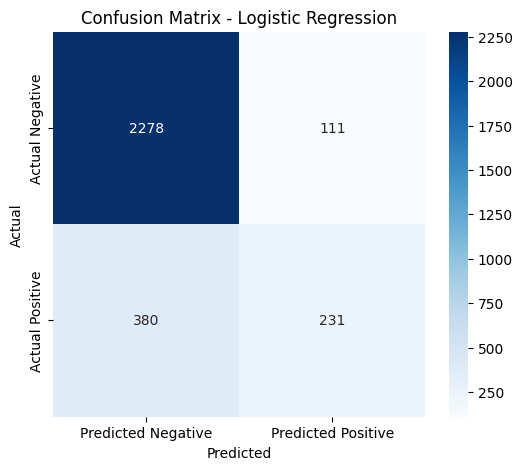

Training Random Forest
Random Forest completed successfully


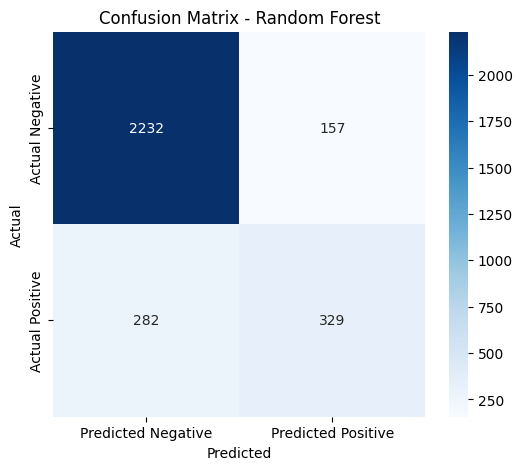

Training SVM
SVM completed successfully


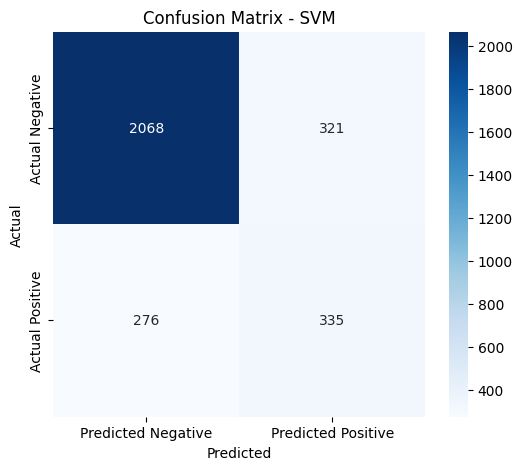

Training Decision Tree
Decision Tree completed successfully


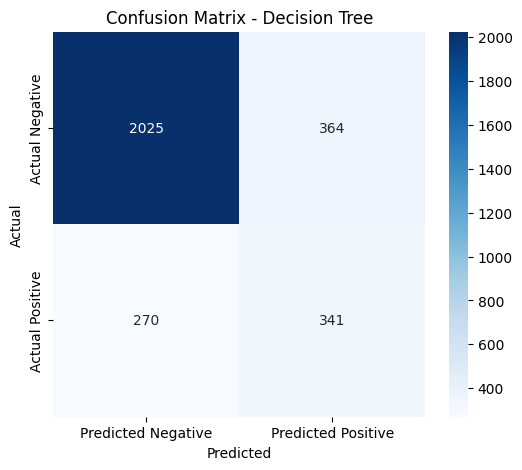

Training XGBoost
XGBoost completed successfully


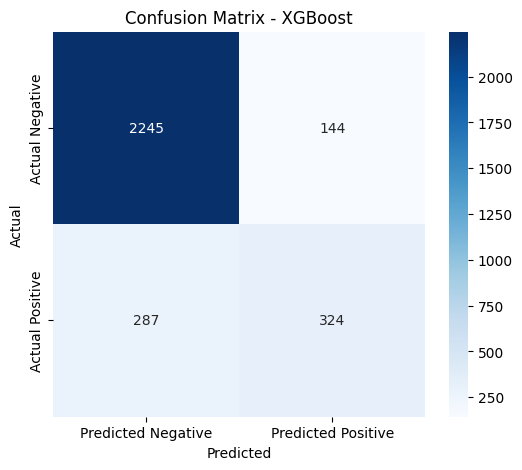

Training Gradient Boosting
Gradient Boosting completed successfully


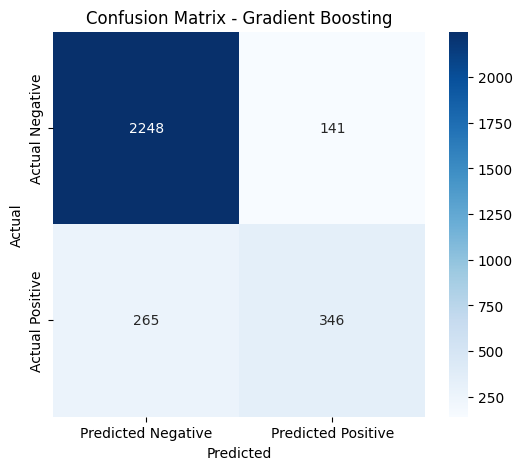

In [55]:
metrics = []


for name, model in models.items():
    try:
        print(f"Training {name}")
        model.fit(X_train_sm, y_train_sm)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]


        cm = confusion_matrix(y_test, y_pred)
        tn, fp, fn, tp = cm.ravel()
        specificity = tn / (tn + fp)

        # Scores
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        auc_score = roc_auc_score(y_test, y_proba)
        mcc = matthews_corrcoef(y_test, y_pred)

        metrics.append({
            "Model": name,
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "Specificity": specificity,
            "F1": f1,
            "AUC": auc_score,
            "MCC": mcc
        })

        print(f"{name} completed successfully")



        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt="d", cmap='Blues',
                   xticklabels=['Predicted Negative', 'Predicted Positive'],
                   yticklabels=['Actual Negative', 'Actual Positive'])
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.title(f'Confusion Matrix - {name}')
        plt.show()

    except Exception as e:
        print(f"{name} failed: {str(e)}")
        metrics.append({
            "Model": name,
            "Accuracy": np.nan,
            "Precision": np.nan,
            "Recall": np.nan,
            "Specificity": np.nan,
            "F1": np.nan,
            "AUC": np.nan,
            "MCC": np.nan
        })

metrics_df = pd.DataFrame(metrics).set_index("Model")

In [60]:
metrics_df.sort_values(by = 'Recall', ascending=False)

,Accuracy,Precision,Recall,Specificity,F1,AUC,MCC
Model,,,,,,,
Gradient Boosting,0.864667,0.710472,0.566285,0.940979,0.630237,0.875674,0.553990
Decision Tree,0.788667,0.483688,0.558101,0.847635,0.518237,0.702868,0.385378
SVM,0.801000,0.510671,0.548282,0.865634,0.528808,0.799183,0.403283
Random Forest,0.853667,0.676955,0.538462,0.934282,0.599818,0.853443,0.516718
XGBoost,0.856333,0.692308,0.530278,0.939724,0.600556,0.853018,0.521643
Logistic Regression,0.836333,0.675439,0.378069,0.953537,0.484785,0.830799,0.420204


In [62]:
# well i chose recall metric as a my primary metric. because losing churners is expensive
# than misflag them. for example:
# it is worse to miss a customer who is about to leave than
# to wrongly flag a loyal customer as churner

## hyperparameter tuning

In [63]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'subsample': [0.7, 0.8, 1.0],
    'min_samples_split': [2, 5, 10]
}

In [68]:
gb = GradientBoostingClassifier(random_state=42)
gradient_search = RandomizedSearchCV(gb, param_grid, scoring='recall', cv=StratifiedKFold(n_splits=5), n_iter=50, n_jobs=-1, verbose=2, random_state=42)
gradient_search.fit(X_train_sm, y_train_sm)
print("GB Grid Search best parameters:", gradient_search.best_params_)
print("GB Grid Search best recall:", gradient_search.best_score_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
GB Grid Search best parameters: {'subsample': 0.8, 'n_estimators': 200, 'min_samples_split': 10, 'max_depth': 5, 'learning_rate': 0.1}
GB Grid Search best recall: 0.839101850882772


In [69]:
best_model = gradient_search.best_estimator_
y_pred_best = best_model.predict(X_test)
y_proba_best = best_model.predict_proba(X_test)[:, 1]

accuracy_tuned = accuracy_score(y_test, y_pred_best)
precision_tuned = precision_score(y_test, y_pred_best)
recall_tuned = recall_score(y_test, y_pred_best)
f1_tuned = f1_score(y_test, y_pred_best)
auc_score_tuned = roc_auc_score(y_test, y_proba_best)
mcc_tuned = matthews_corrcoef(y_test, y_pred_best)



print(f'Accuracy: {accuracy_tuned}, \nPrecision: {precision_tuned}, \nRecall: {recall_tuned}')
print(f'F1-score: {f1_tuned}, \nAuc: {auc_score_tuned}, \nMCC: {mcc_tuned}')

Accuracy: 0.864, 
Precision: 0.7182795698924731, 
Recall: 0.546644844517185
F1-score: 0.620817843866171, 
Auc: 0.8684231259064493, 
MCC: 0.5472814659164481


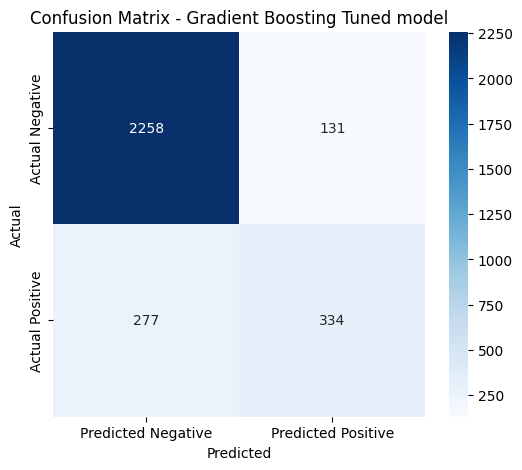

In [70]:
cm_tuned = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_tuned, annot=True, fmt="d", cmap='Blues',
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - Gradient Boosting Tuned model')
plt.show()

well, in here tuning made results slightly worse. because of i think we used SMOTE to handle the class imbalance. My model is overfitting now. because it memorize synthetic data. in my test set there are no any synthetic data.

to handle this we should remove all of the synthetic and use XGboost model with scale_weight_pos parameter.
then we should tune XGBoost too.

But i think this technical task is to see my skills. I can build end-to-end machine learning pipeline. Thats why, i want to stop here.

What can i do in the future for this pipeline. try to find better dataset, or i can do cross_domain which means combining couple datasets to balance classes.

I can show and explain why my model making such a prediction by using SHAP and feature permutation algorithms.

I want to explain my model metrics now. accuracy is fine but recall is low 54% which means we are losing almost 40% of churners. MCC is low too 54% coz of class imbalance.
In the confusion matrix. we can see my model did good job on 'actual negative' 2258 which means people who will stay, and predicted poorly on 'actual positive' 334 which means churners.

## ***NOT***

well. i think company should take action before customer decided to leave, how company knows about people start to think about leave. in this case they should use information which are number of products, balance and active status. for example person who is inactive but has high balance, is seeking new invesments. so in this case company should contact them personally and offer them new products and facilities. in this way if person has more products with company, it engage customer to company which makes hard to leave. Communication is important, every message should be personalized based on their interests. Additionally, company should take account of place, with this information company can approach differenly based on country. Company should take risk, such as it is obvious company can not handle all of customers or can not contact all of them either. so in this case company should leave customer who already gone. by using data such as active status, number of products and tenure, company can find out the percentage of person which is already left or not. company should contact people who are thinking about leaving. in this way company save time, money and energy.
Finally, company should prioritize the customer value, i meant not only calculating churners, company should focus on active and high balance customers too